IN 7TH ADD AGLOEMARTIVE & DBSCAN IN KMEANS
AND DOC MEIN COMPARE THEM

IN 8TH COMPARE K MEANS WITH EM JUST ADD NOISE

In [29]:
# Run this only if packages are missing
%pip install -q numpy matplotlib pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


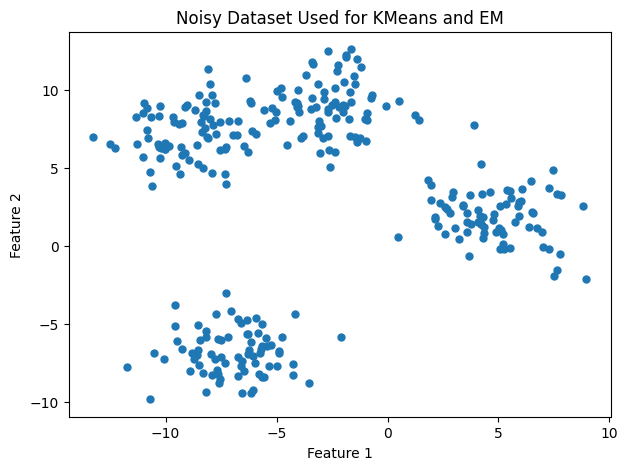

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

# Base dataset
X_clean, y_true = make_blobs(
    n_samples=300,
    centers=4,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

# Add Gaussian noise directly to dataset used by models
noise = np.random.normal(loc=0.0, scale=0.8, size=X_clean.shape)
X = X_clean + noise

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=25)
plt.title("Noisy Dataset Used for KMeans and EM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

KMeans + Agglomerative + DBSCAN Results
KMeans   -> Inertia: 1586.2415, Silhouette: 0.6529
Agglo    -> Silhouette: 0.6517
DBSCAN   -> Clusters: 3, Silhouette: 0.5452448483839195


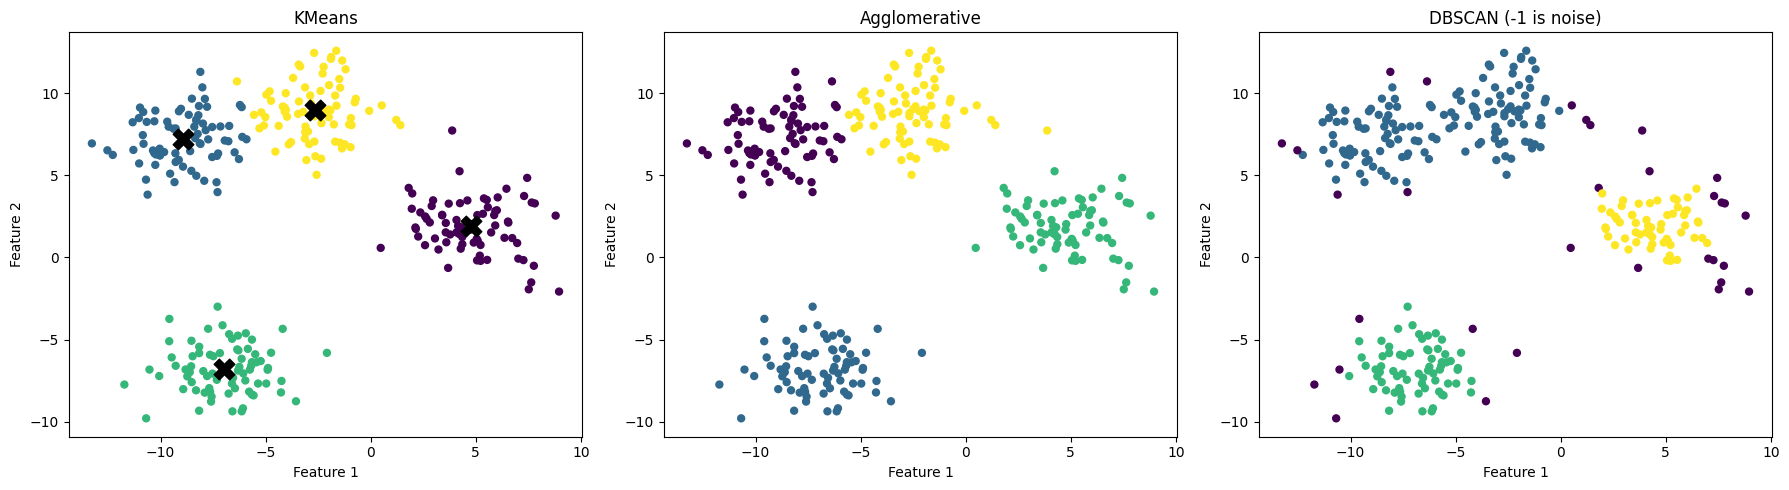

In [31]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# ---------- KMEANS + AGGLOMERATIVE + DBSCAN ----------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X)

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X)

dbscan = DBSCAN(eps=1.2, min_samples=6)
dbscan_labels = dbscan.fit_predict(X)

# Metrics
kmeans_inertia = kmeans.inertia_
kmeans_silhouette = silhouette_score(X, kmeans_labels)
agg_silhouette = silhouette_score(X, agg_labels)

dbscan_cluster_count = len(set(dbscan_labels) - {-1})
if dbscan_cluster_count >= 2:
    dbscan_silhouette = silhouette_score(X, dbscan_labels)
else:
    dbscan_silhouette = float("nan")

print("KMeans + Agglomerative + DBSCAN Results")
print(f"KMeans   -> Inertia: {kmeans_inertia:.4f}, Silhouette: {kmeans_silhouette:.4f}")
print(f"Agglo    -> Silhouette: {agg_silhouette:.4f}")
print(f"DBSCAN   -> Clusters: {dbscan_cluster_count}, Silhouette: {dbscan_silhouette}")

# Quick visual for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=25)
axes[0].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=220,
    c="black"
)
axes[0].set_title("KMeans")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X[:, 0], X[:, 1], c=agg_labels, s=25)
axes[1].set_title("Agglomerative")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

axes[2].scatter(X[:, 0], X[:, 1], c=dbscan_labels, s=25)
axes[2].set_title("DBSCAN (-1 is noise)")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

EM (GMM) Results
Log Likelihood: -5.164090002194771
Silhouette Score: 0.6524276566883662


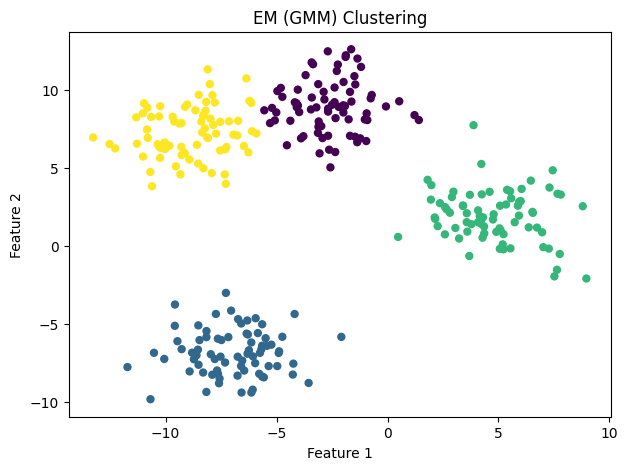

In [32]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# ---------- EM (GMM) ONLY ----------
gmm = GaussianMixture(n_components=4, random_state=42)
em_labels = gmm.fit_predict(X)

em_log_likelihood = gmm.score(X)
em_silhouette = silhouette_score(X, em_labels)

print("EM (GMM) Results")
print("Log Likelihood:", em_log_likelihood)
print("Silhouette Score:", em_silhouette)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=em_labels, s=25)
plt.title("EM (GMM) Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Comparison: KMeans vs Agglomerative vs DBSCAN
--------------------------------------------------
KMeans silhouette: 0.6529
Agglomerative silhouette: 0.6517
DBSCAN clusters found: 3
DBSCAN silhouette: 0.5452


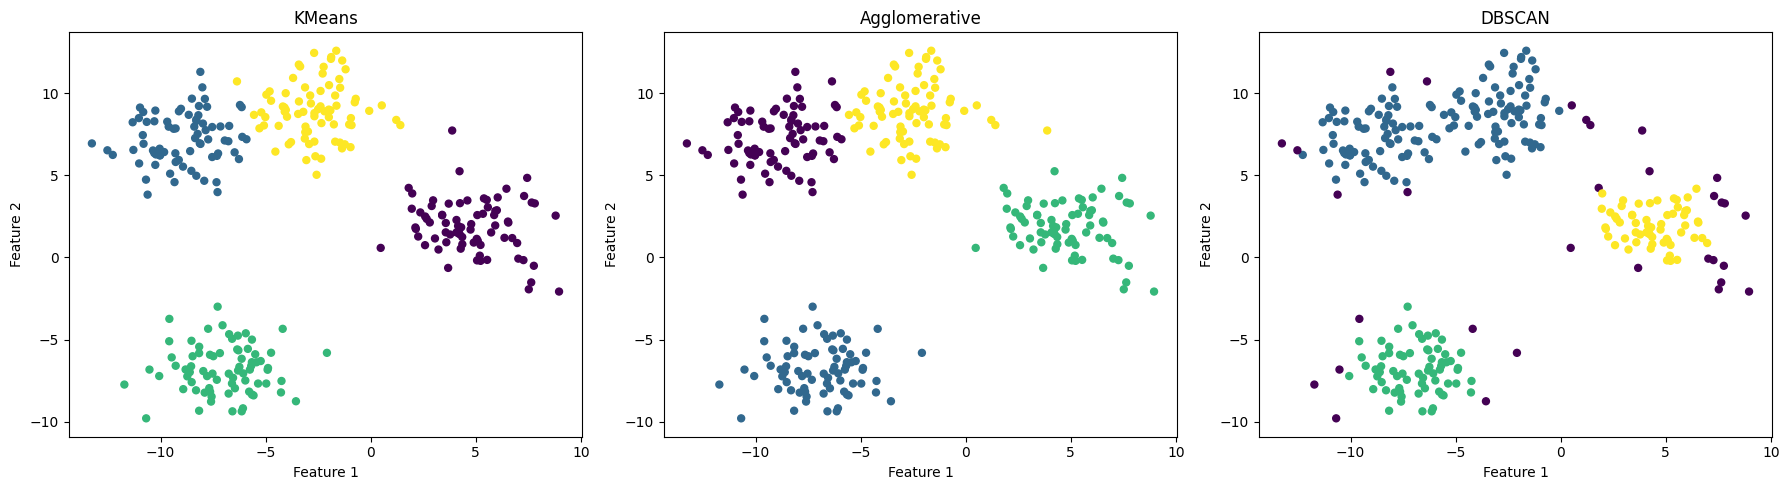

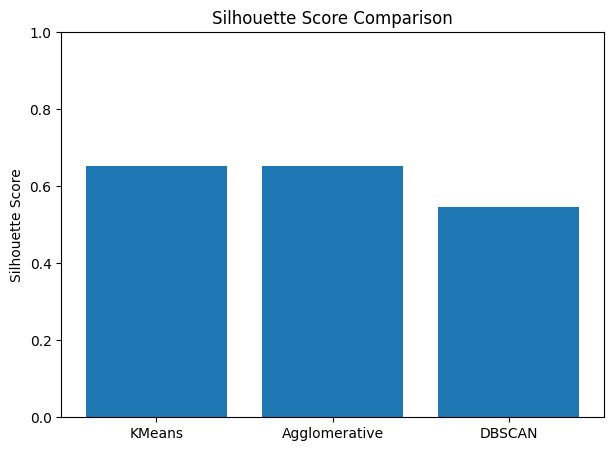

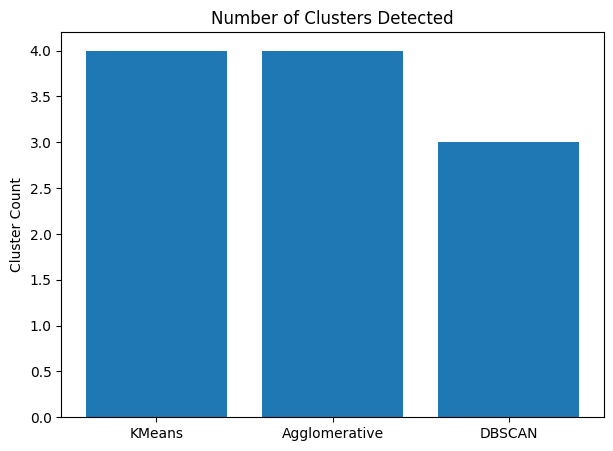

In [33]:
import numpy as np
import matplotlib.pyplot as plt

print("Comparison: KMeans vs Agglomerative vs DBSCAN")
print("-" * 50)
print(f"KMeans silhouette: {kmeans_silhouette:.4f}")
print(f"Agglomerative silhouette: {agg_silhouette:.4f}")
print(f"DBSCAN clusters found: {dbscan_cluster_count}")
if np.isnan(dbscan_silhouette):
    print("DBSCAN silhouette: N/A (needs at least 2 clusters)")
else:
    print(f"DBSCAN silhouette: {dbscan_silhouette:.4f}")

# 1) Scatter comparison graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=25)
axes[0].set_title("KMeans")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X[:, 0], X[:, 1], c=agg_labels, s=25)
axes[1].set_title("Agglomerative")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

axes[2].scatter(X[:, 0], X[:, 1], c=dbscan_labels, s=25)
axes[2].set_title("DBSCAN")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# 2) Silhouette comparison bar graph (for valid values)
model_names = ["KMeans", "Agglomerative", "DBSCAN"]
scores = [kmeans_silhouette, agg_silhouette, dbscan_silhouette]
plot_scores = [np.nan if np.isnan(s) else s for s in scores]

plt.figure(figsize=(7, 5))
plt.bar(model_names, plot_scores)
plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
plt.show()

# 3) Cluster count comparison graph
cluster_counts = [
    len(set(kmeans_labels)),
    len(set(agg_labels)),
    len(set(dbscan_labels) - {-1})
]

plt.figure(figsize=(7, 5))
plt.bar(model_names, cluster_counts)
plt.title("Number of Clusters Detected")
plt.ylabel("Cluster Count")
plt.show()

Average noise magnitude: 0.976
Max noise magnitude: 3.110
High-noise points (top 10%): 30
DBSCAN noise points: 32


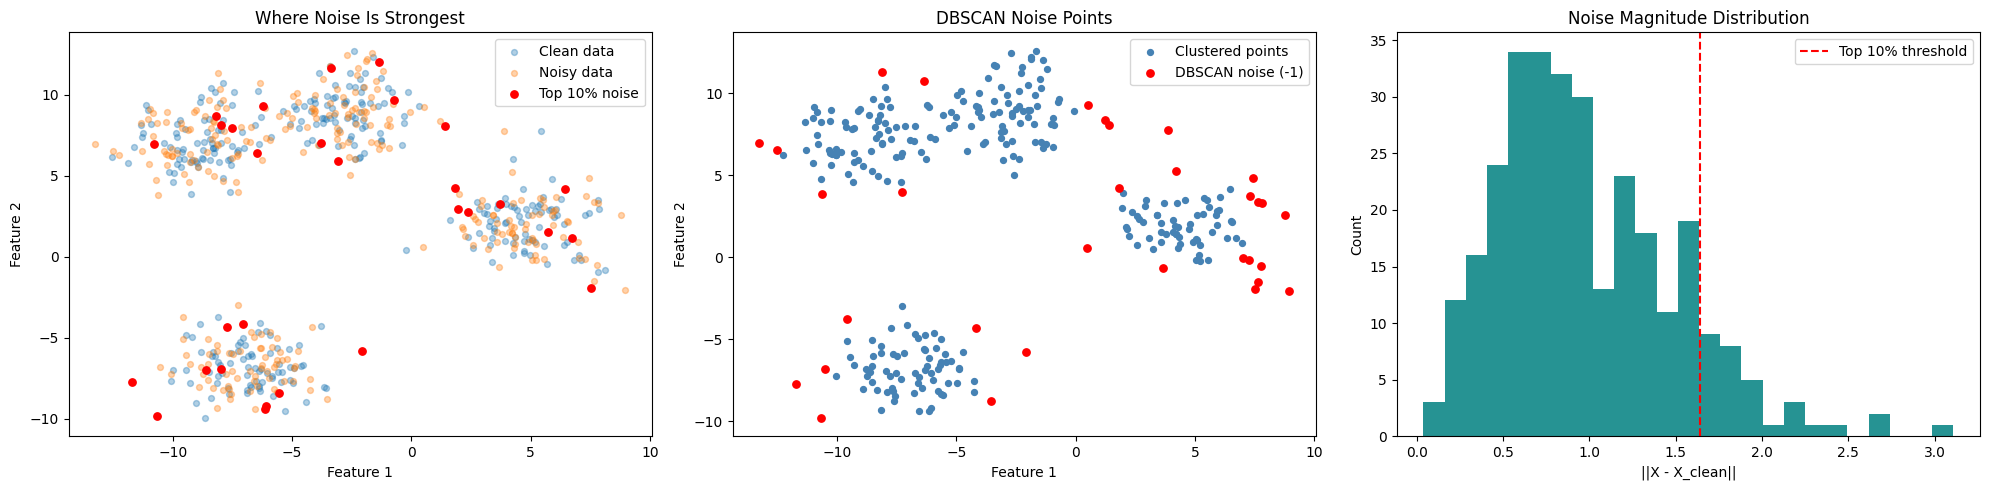

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Noise visualization -----
# Point-wise noise magnitude between clean and noisy dataset
noise_magnitude = np.linalg.norm(X - X_clean, axis=1)

# Top 10% most disturbed points
high_noise_threshold = np.quantile(noise_magnitude, 0.90)
high_noise_mask = noise_magnitude >= high_noise_threshold

# DBSCAN noise points are labeled as -1
dbscan_noise_mask = dbscan_labels == -1

print(f"Average noise magnitude: {noise_magnitude.mean():.3f}")
print(f"Max noise magnitude: {noise_magnitude.max():.3f}")
print(f"High-noise points (top 10%): {high_noise_mask.sum()}")
print(f"DBSCAN noise points: {dbscan_noise_mask.sum()}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Clean vs noisy with highlighted high-noise points
axes[0].scatter(X_clean[:, 0], X_clean[:, 1], s=18, alpha=0.35, label="Clean data")
axes[0].scatter(X[:, 0], X[:, 1], s=18, alpha=0.35, label="Noisy data")
axes[0].scatter(X[high_noise_mask, 0], X[high_noise_mask, 1], c="red", s=28, label="Top 10% noise")
axes[0].set_title("Where Noise Is Strongest")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

# 2) DBSCAN view: explicit noise points in red
axes[1].scatter(X[~dbscan_noise_mask, 0], X[~dbscan_noise_mask, 1], c="steelblue", s=18, label="Clustered points")
axes[1].scatter(X[dbscan_noise_mask, 0], X[dbscan_noise_mask, 1], c="red", s=28, label="DBSCAN noise (-1)")
axes[1].set_title("DBSCAN Noise Points")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

# 3) Histogram of noise magnitude
axes[2].hist(noise_magnitude, bins=25, color="teal", alpha=0.85)
axes[2].axvline(high_noise_threshold, color="red", linestyle="--", label="Top 10% threshold")
axes[2].set_title("Noise Magnitude Distribution")
axes[2].set_xlabel("||X - X_clean||")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Optional: robustness check with noise
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.8, size=X.shape)
X_noisy = X + noise

# KMeans on noisy data
kmeans_noisy = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_noisy = kmeans_noisy.fit_predict(X_noisy)
sil_kmeans_noisy = silhouette_score(X_noisy, labels_kmeans_noisy)

# EM on noisy data
gmm_noisy = GaussianMixture(n_components=4, random_state=42)
labels_em_noisy = gmm_noisy.fit_predict(X_noisy)
sil_em_noisy = silhouette_score(X_noisy, labels_em_noisy)

print("Noise Robustness Check")
print("KMeans silhouette on noisy data:", sil_kmeans_noisy)
print("EM(GMM) silhouette on noisy data:", sil_em_noisy)

Noise Robustness Check
KMeans silhouette on noisy data: 0.6217060439571152
EM(GMM) silhouette on noisy data: 0.6217060439571152
